In [1]:
"""
sandbox.ipynb

A sandbox to play around with new analyses.

Author: Stellina X. Ao
Created: 2026-03-05
Last Modified: 2026-03-23
Python Version: 3.11.14
"""

from squiggs.neuron_viewer import NeuronViewer
from squiggs.renderers import FitRenderer
from sg.fitter import LVMFamily
from sg.eval_models import plot_summary

import scienceplots  # noqa: F401
import shutup
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

%load_ext autoreload
%autoreload 2

# pretty plots
plt.style.use(["nature"])
plt.rcParams["figure.dpi"] = 200
%matplotlib widget
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

# suppress warnings :-)
shutup.please()

In [ ]:
"""
TODO:
backburner
- what about adding ReLU to the taskvar model and removing block?
- plot rasters, sanity check the psths
"""

In [ ]:
# check if you can get back m2 z-score psths from dividing tuber
# ask joao about the masking of the problem via zscore

## Fit 

In [2]:
from core.data import load_sess

subj_id = "MM012"
sess_idx = 5

unit_spike_times, trial_data, session_data, regions = load_sess(
    subj_id="MM012", sess_idx=5, mode="old"
)

MM012 20231219_130847


In [3]:
family = LVMFamily(
    trial_data=trial_data,
    spike_times=unit_spike_times,
    session_data=session_data,
    regions=regions,
    n_latents_mult=1,
    n_latents_addt=1,
    sanity_check=0,
    task_vars=[
        "response",
        "rewarded",
        "block_side",
        "strategy",
        "response_prev",
        "rewarded_prev",
    ],
    tpre=0.5,
    tpost=1,
    refit=True,
    max_iter=10,
    norm_activity=True,
)
family.fit_all()
family.eval()

267
[41, 25, 26, 31, 30, 25, 30, 31, 24, 37, 34, 30, 30, 22, 26, 25, 24, 38, 27, 22, 25, 15, 14, 12, 22, 15, 20, 18, 23, 21, 25, 47, 35, 33, 26, 28, 26, 31, 18, 24, 18, 31, 21, 17, 32, 30, 18, 19, 9, 23, 15, 17, 26, 31, 20, 16, 18, 54, 34, 36, 23, 25, 26, 26, 44, 22, 27, 15, 29, 38, 18, 25, 22, 21, 25, 23, 16, 15, 10, 17, 16, 13, 18, 21, 50, 32, 24, 23, 32, 17, 22, 24, 25, 27, 21, 29, 17, 22, 28, 12, 15, 20, 26, 13, 17, 21, 18, 11, 12, 39, 31, 29, 26, 19, 8, 15, 23, 19, 21, 45, 33, 38, 38, 11, 15, 26, 20, 33, 23, 15, 20, 19, 8, 52, 30, 30, 19, 17, 49, 35, 27, 24, 26, 23, 36, 35, 23, 20, 15, 24, 22, 11, 18, 19, 18, 24, 14, 19, 19, 40, 28, 22, 19, 26, 23, 28, 27, 26, 26, 23, 23, 16, 19, 17, 25, 25, 16, 15, 8, 23, 17, 15, 19, 16, 22, 9, 20, 47, 22, 22, 28, 30, 23, 26, 22, 20, 20, 21, 21, 20, 21, 23, 20, 17, 20, 19, 19, 15, 10, 22, 19, 15, 14, 10, 38, 33, 28, 36, 36, 20, 22, 22, 27, 15, 32, 26, 45, 15, 23, 14, 19, 21, 15, 22, 8, 16, 23, 21, 21, 12, 18, 13, 46, 31, 24, 22, 21, 38, 20, 23, 2

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


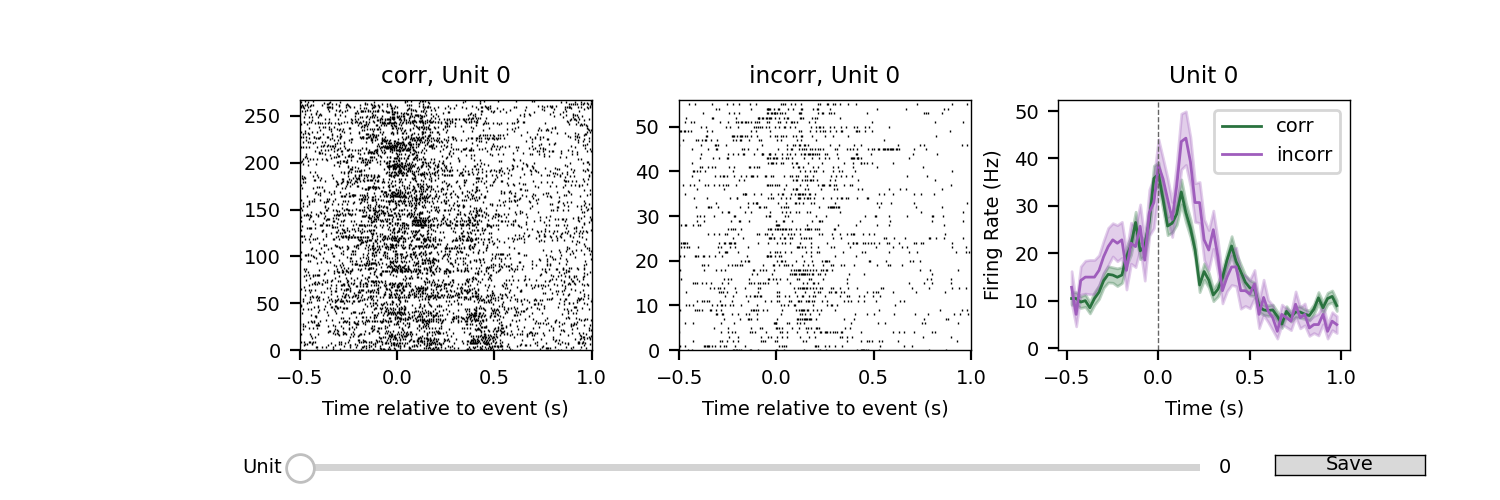

In [4]:
from squiggs.renderers import PETHRasterRenderer
from core.data import get_psths_cond, get_choice_ts
from utils.paths import FIGURES_DIR

reg = "DLS"
mode = "rewarded"

renderer = PETHRasterRenderer(
    event_times=get_choice_ts(family.trial_data, mode=mode),
    spike_times=family.spike_times[reg],
    peths=get_psths_cond(
        family.psths[reg], family.trial_data, family.trial_mask, mode=mode
    ),
    pres=0.5,
    posts=1,
    binwidth_s=25 / 1000,
    s=1,
    linewidths=0.5,
    save_subdir=Path("peths") / subj_id / str(sess_idx) / reg / mode,
)

nv = NeuronViewer(
    num_units=family.psths[reg].shape[0], render_func=renderer, fig_dir=FIGURES_DIR
)

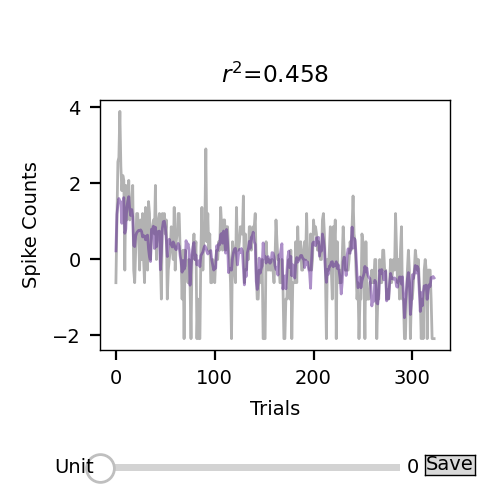

In [5]:
renderer = FitRenderer(
    family.mod_affine,
    x=family.test_dl.dataset[:],
    y=family.robs,
    save_subdir=Path("model_fits") / "0312-lm" / "offset",
)

nv = NeuronViewer(num_units=renderer.y.shape[1], render_func=renderer)

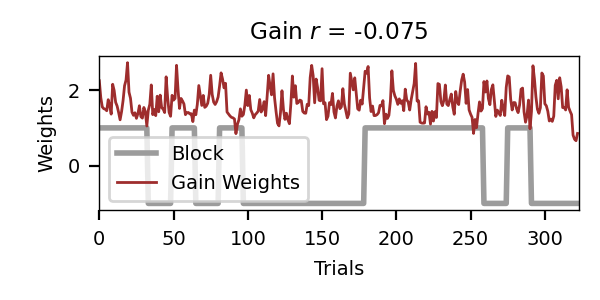

In [6]:
_ = plot_summary(family, model=family.mod_gain, potato=family.strategy, mode="gain")

### Delta R2, R2

In [ ]:
from sg.eval_models import monkey_cv_d_r2, plot_cv_d_r2

scramble_r2s, scramble_r2s_summary = monkey_cv_d_r2(
    trial_data, unit_spike_times, session_data, regions
)
plot_cv_d_r2(scramble_r2s_summary)

### Strategy Decoding from Latents

In [ ]:
from sg.eval_models import latent_decoding, get_scores_mean
from pprint import pprint

scores = latent_decoding(family)
pprint(get_scores_mean(scores))

### cweights

In [ ]:
task_vars = family.task_vars
task_vars_str = {
    "response": ["left", "right"],
    "rewarded": ["no", "yes"],
    "block_side": ["left", "right"],
    "strategy": ["MF", "MB"],
    "response_prev": ["left", "none", "right"],
    "rewarded_prev": ["no", "yes"],
}

In [ ]:
import matplotlib.colors as colors
import matplotlib.cm as cm


def plot_cweights(family, mode, ax0=0, ax1=1):
    model = family.mod_gain if mode == "gain" else family.mod_offset

    coupling = (
        model.readout_gain.weight.data[:].T
        if mode == "gain"
        else mode.readout_offset.weight.data
    )

    i = 0
    for pivot in task_vars_str.keys():
        fig, axes = plt.subplots(
            ncols=len(task_vars_str[pivot]), figsize=(2 * len(task_vars_str[pivot]), 2)
        )

        for val, ax in zip(task_vars_str[pivot], axes.flat):
            taskvar_weights = family.mod_taskvar.tv.weight.data[:][i]

            norm = colors.Normalize(
                vmin=taskvar_weights.min(), vmax=taskvar_weights.max()
            )
            cmap = cm.viridis
            mapped_colors = cmap(norm(taskvar_weights))

            ax.scatter(coupling[:, ax0], coupling[:, ax1], color=mapped_colors, s=0.5)

            ax.set_xlabel("Latent 1")
            ax.set_ylabel("Latent 2")
            ax.set_title(f"{pivot}_{val}")

            i += 1

        fig.suptitle(pivot)
        fig.tight_layout()


plot_cweights(family, mode="gain", ax0=0, ax1=1)

In [ ]:
from sg.eval_models import plot_cweights_mult

plot_cweights_mult(family)

### gs n. latents 

In [ ]:
import importlib
import sg

importlib.reload(sg)

In [ ]:
from sg.eval_models import get_latent_r

subj_ids = ["MM012", "MM012", "MR82", "MR83"]
sess_idxs = [4, 5, 5, 5]
modes = ["old", "old", "new", "new"]

i = 2

folders = ["all", "ACC", "DMS", "M2", "DLS"]


def get_r2s_helper(subj_id, sess_idx, mode, folders, n_m=5):
    r2s = {}
    unit_spike_times, trial_data, session_data, regions = load_sess(
        subj_id=subj_id, sess_idx=sess_idx, mode=mode
    )
    for f in folders:
        r2s[f] = get_latent_r(
            trial_data,
            unit_spike_times,
            session_data,
            regions,
            subj_id=subj_id,
            sess_idx=sess_idx,
            folder=f,
            n_m=n_m,
            do_plot=True,
        )

In [ ]:
from pprint import pprint

for i in range(4):
    unit_spike_times, trial_data, session_data, regions = load_sess(
        subj_id=subj_ids[i], sess_idx=sess_idxs[i], mode=modes[i]
    )

    family = LVMFamily(
        trial_data=trial_data,
        spike_times=unit_spike_times,
        session_data=session_data,
        regions=regions,
        n_latents_mult=3,
        n_latents_addt=1,
        sanity_check=0,
        task_vars=[
            "response",
            "rewarded",
            "block_side",
            "strategy",
            "response_prev",
            "rewarded_prev",
        ],
        tpre=0.5,
        tpost=1,
        refit=True,
        max_iter=10,
        norm_activity=True,
    )
    family.get_data()
    pprint({reg: len(family.psths[reg]) for reg in regions})

In [ ]:
i = 2
get_r2s_helper(subj_ids[i], sess_idxs[i], modes[i], folders=["DLS"], n_m=5)

### res dfs filtering stuff

In [ ]:
from sg.eval_models import get_res

res = get_res(family, mode="taskvar")
radish = np.mean(res, axis=1)
bacon = np.std(res, axis=1)

In [ ]:
# 1. why is res.shape = (332, 150) but dfs.shape = (332, 154)
# -> how is robs filtered?
# 2. is the filtered array (with the offending neurons filtered out) passed to the lvms?
#    -> because it's still learning a major affect present in only 6 neurons

In [ ]:
res.shape

In [ ]:
np.where(np.abs(res[149, :]) > 5)

In [ ]:
plt.figure()
plt.hist(res[149, :])
plt.show()

In [ ]:
family.sample["dfs"][
    :, family.cids
].shape  # = robs.shape, makes sense beceause robs is filtered with cids

In [ ]:
plt.figure()
plt.plot(radish)
plt.fill_between(np.arange(len(radish)), radish - bacon, radish + bacon, alpha=0.5)
plt.show()

In [ ]:
plt.figure()
plt.imshow(family.data_gd.covariates["dfs"])
plt.show()

In [ ]:
_ = plot_summary(family, model=family.mod_offset, potato=bacon, mode="offset")

In [ ]:
plt.figure()
plt.imshow(family.robs.T, aspect="auto")
plt.show()